In [1]:
from PIL import Image, ImageChops, ImageDraw, ImageFont
import random
from faker import Faker

from scripts.utils import crop_to_content
from scripts.template_1 import create_invoice_template_1, example_template_1
from scripts.template_2 import create_invoice_template_2, example_template_2
from scripts.template_3 import create_invoice_template_3, example_template_3
from scripts.template_4 import create_invoice_template_4, example_template_4
from scripts.template_5 import create_invoice_template_5, example_template_5

from scripts.texture_1 import create_texture_1, apply_paper_texture_1
from scripts.noise_1 import add_noise_1

In [2]:
fake = Faker("id_ID")

### Data

In [3]:
def random_company():
    prefixes = [
        "PT",
        "CV",
    ]

    business_words = [
        "Maju",
        "Digital",
        "Teknologi",
        "Solusi",
        "Mitra",
        "Inovasi",
        "Nusantara",
        "Sinar",
        "Prima",
        "Global",
        "Cipta",
        "Berkah",
        "Sentosa",
        "Sejahtera",
        "Abadi",
    ]

    suffixes = [
        "Jaya",
        "Indonesia",
        "Nusantara",
        "Digital",
        "Teknologi",
        "Solutions",
        "Informatika",
        "Sejahtera",
        "Mandiri",
        "Abadi",
    ]

    return f"{random.choice(prefixes)} {random.choice(business_words)} {random.choice(suffixes)}"


def random_street():
    return fake.street_address()


def random_city():
    return f"{fake.city()}, Indonesia"


def random_service():
    return random.choice([
        "Software Development",
        "Mobile App Development",
        "Web Development",
        "UI/UX Design",
        "Cloud Infrastructure",
        "Technical Support",
        "System Maintenance",
        "Database Management",
        "API Development",
        "DevOps Services",
        "Data Processing",
        "AI Development",
        "Machine Learning Development",
        "IT Consulting",
        "Software Testing",
    ])


def random_bank():
    return random.choice([
        "Bank Mandiri",
        "Bank Central Asia",
        "Bank Negara Indonesia",
        "Bank Rakyat Indonesia",
        "Bank CIMB Niaga",
        "Bank Permata",
    ])


def random_note():
    return random.choice([
        "Payment is due within 30 days from the invoice date.",
        "Payment is due within 14 days from the invoice date.",
        "Please make payment before the due date.",
        "Thank you for your business.",
        "Payment must be completed according to the agreed terms.",
        "Please include the invoice number with your payment.",
    ])


def _random_price():
    return random.randint(5, 100) * 50_000

In [4]:
def _random_phone():
    return f"+62 8{random.randint(10, 99)}-{random.randint(1000, 9999)}-{random.randint(1000, 9999)}"


def _random_email(company_name, prefix):
    domain = (
        company_name.lower()
        .replace("pt ", "")
        .replace(" ", "")
    )

    return f"{prefix}@{domain}.com"

### Generative Invoice Data

In [21]:
def generate_invoice_data(
    min_items=2,
    max_items=6,
):
    # =========================================================
    # COMPANY
    # =========================================================

    bill_to_company = random_company()
    from_company = random_company()

    bill_to = {
        "name": bill_to_company,
        "address": random_street(),
        "city": random_city(),
        "phone": _random_phone(),
        "email": _random_email(bill_to_company, "finance"),
    }

    from_to = {
        "name": from_company,
        "address": random_street(),
        "city": random_city(),
        "phone": _random_phone(),
        "email": _random_email(from_company, "billing"),
    }

    # =========================================================
    # DATE & INVOICE NUMBER
    # =========================================================

    day = random.randint(1, 28)
    month = random.randint(1, 12)
    year = random.choice([2025, 2026, 2027])

    months = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]

    invoice_date = f"{day} {months[month - 1]} {year}"

    invoice_no = (
        f"INV-{year}-"
        f"{random.randint(1, 99999):05d}"
    )

    # =========================================================
    # ITEMS
    # =========================================================

    num_items = random.randint(
        min_items,
        max_items,
    )

    items = []

    for _ in range(num_items):
        service = random_service()

        qty = random.randint(1, 10)
        price = _random_price()
        total = qty * price

        items.append({
            "description": service,
            "qty": qty,
            "price": price,
            "total": total,
        })

    subtotal = sum(
        item["total"]
        for item in items
    )

    # =========================================================
    # PAYMENT
    # =========================================================

    bank = random_bank()

    payment_information = {
        "bank": bank,
        "account_name": from_company,
        "account_number": str(
            random.randint(
                1000000000,
                9999999999,
            )
        ),
        "email": from_to["email"],
    }

    # =========================================================
    # RESULT
    # =========================================================

    return {
        "bill_to": bill_to,
        "invoice_date": invoice_date,
        "invoice_no": invoice_no,
        "from_to": from_to,
        "items": items,
        "subtotal": subtotal,
        "note": random_note(),
        "payment_information": payment_information,
    }

### Create Invoice Image

In [22]:
def generate_invoice_image():
    invoice_data = generate_invoice_data()

    # Random invoice template
    template_id = random.randint(1, 5)

    invoice_templates = {
        1: create_invoice_template_1,
        2: create_invoice_template_2,
        3: create_invoice_template_3,
        4: create_invoice_template_4,
        5: create_invoice_template_5,
    }

    invoice = invoice_templates[template_id](
        **invoice_data
    )

    width, height = invoice.size

    # Random paper texture
    texture = create_texture_1(
        width,
        height,
        num_wrinkles=random.randint(2, 8),
    )

    # Random paper deformation / shading
    invoice = apply_paper_texture_1(
        invoice,
        texture,
        displacement=random.uniform(2, 8),
        shading_strength=random.uniform(0.10, 0.30),
    )

    # Random stains / noise
    invoice = add_noise_1(
        invoice,
        stain_count=random.randint(30, 120),
        speckle_count=random.randint(100, 600),
        stain_opacity=(
            random.randint(5, 12),
            random.randint(20, 40),
        ),
        speckle_opacity=(
            random.randint(5, 15),
            random.randint(25, 45),
        ),
        stain_size=(
            random.randint(5, 20),
            random.randint(60, 120),
        ),
        grain_strength=random.uniform(0.5, 3.0),
    )

    return invoice, invoice_data

In [24]:
data = generate_invoice_image()

In [25]:
data[1]

{'bill_to': {'name': 'CV Sejahtera Sejahtera',
  'address': 'Jl. Surapati No. 442',
  'city': 'Lhokseumawe, Indonesia',
  'phone': '+62 811-8159-1556',
  'email': 'finance@cvsejahterasejahtera.com'},
 'invoice_date': '5 June 2026',
 'invoice_no': 'INV-2026-28163',
 'from_to': {'name': 'CV Sinar Abadi',
  'address': 'Jl. Joyoboyo No. 85',
  'city': 'Bandung, Indonesia',
  'phone': '+62 850-1108-4270',
  'email': 'billing@cvsinarabadi.com'},
 'items': [{'description': 'Software Testing',
   'qty': 5,
   'price': 2450000,
   'total': 12250000},
  {'description': 'Machine Learning Development',
   'qty': 3,
   'price': 4750000,
   'total': 14250000},
  {'description': 'Database Management',
   'qty': 8,
   'price': 4200000,
   'total': 33600000},
  {'description': 'Database Management',
   'qty': 9,
   'price': 4450000,
   'total': 40050000},
  {'description': 'Data Processing',
   'qty': 5,
   'price': 4250000,
   'total': 21250000}],
 'subtotal': 121400000,
 'note': 'Thank you for your b

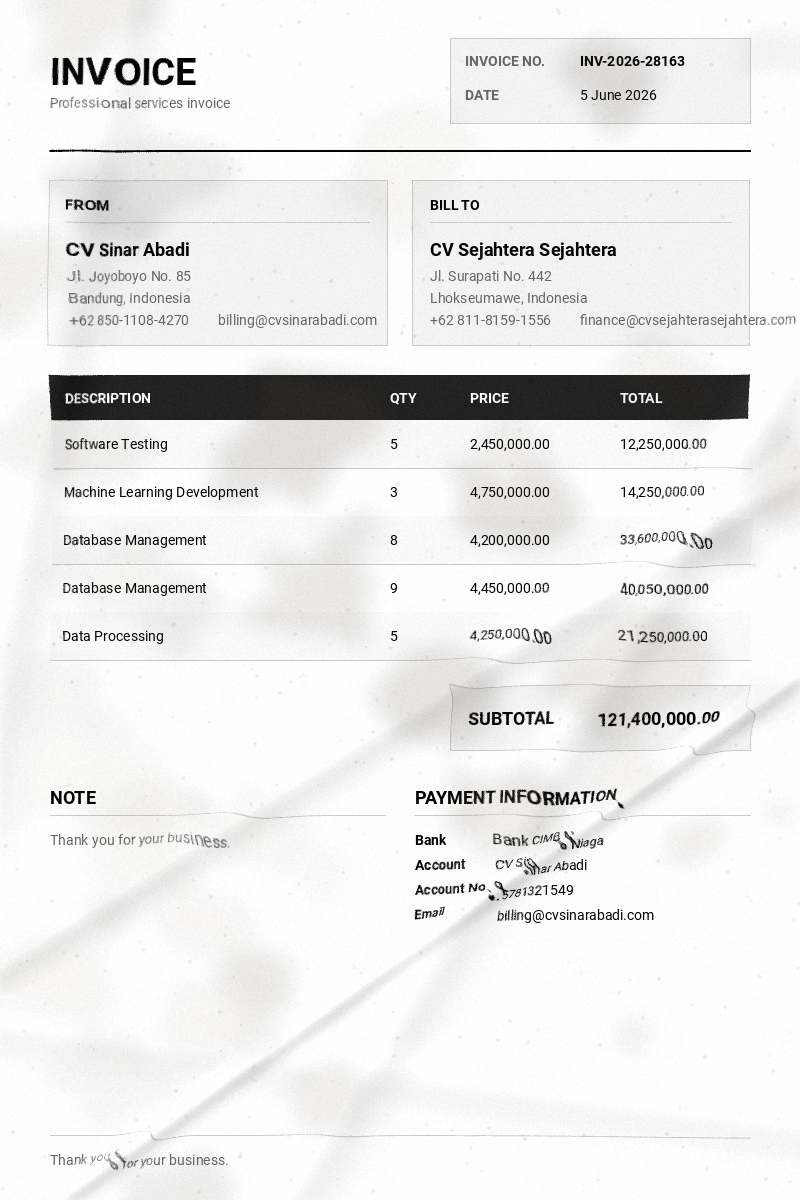

In [26]:
data[0]